# DEVELOPERSHUB CORPORATION

# Task 4: Predicting Insurance Claim Amounts 
# ‎Objective: 
# ‎ Estimate the medical insurance claim amount based on personal data. 
# ‎Dataset: 
# ‎ Medical Cost Personal Dataset 
# ‎Instructions: 
# ‎● Train a Linear Regression model to predict charges. 
# ‎● Visualize how BMI, age, and smoking status impact insurance charges. 
# ‎● Evaluate model performance using MAE and RMSE.
# ‎Skills: 
# ‎● Regression modeling 
# ‎● Feature correlation and visualization 
# ‎● Error evaluation using MAE and RMSE

In [1]:
import pandas as pd
df = pd.read_csv('insurance.csv')

INSURANCE CLAIM AMOUNT PREDICTION
Dataset shape: (1338, 7)

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

DATA CLEANING

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Shape after cleaning: (1338, 7)

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960

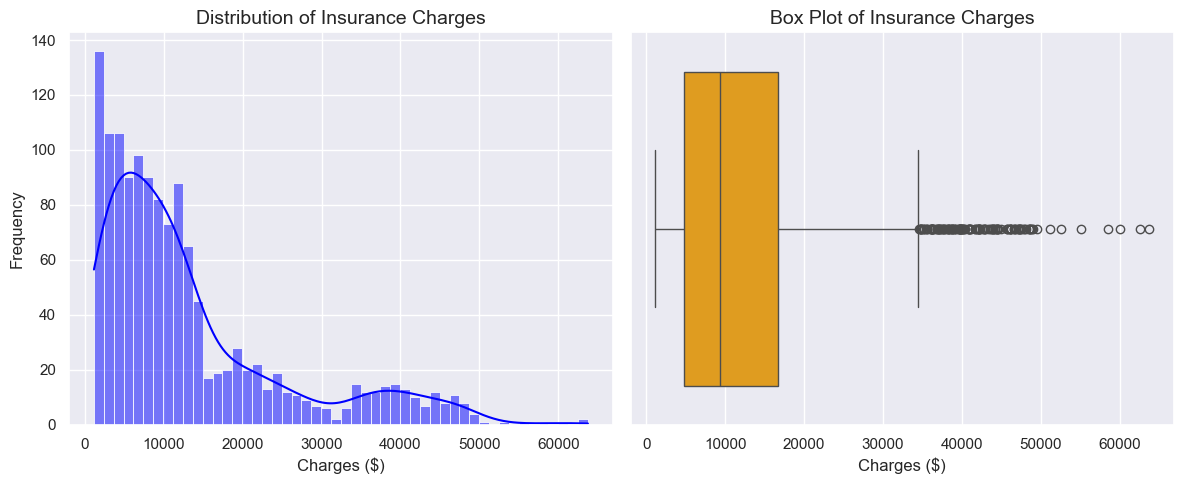

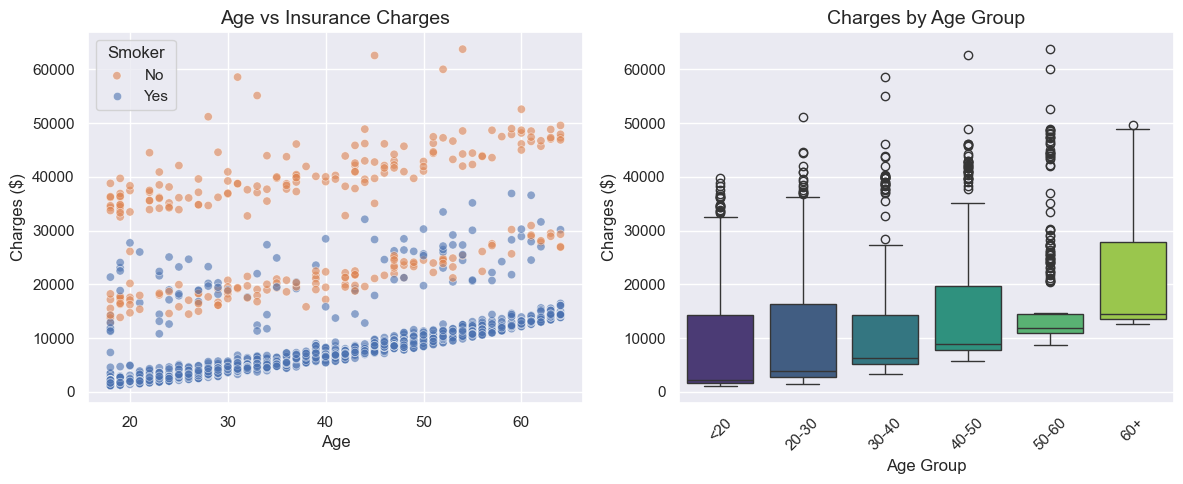

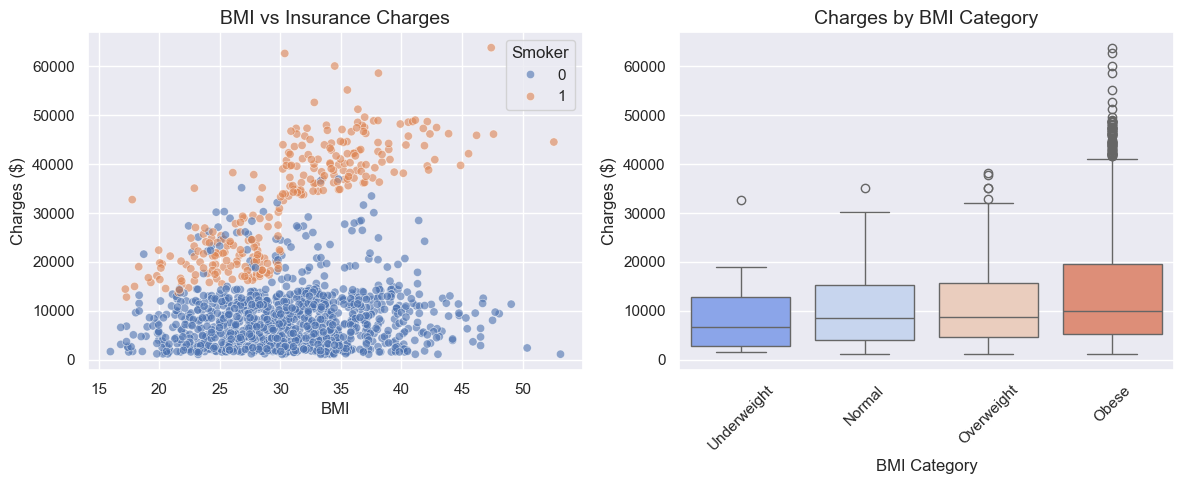

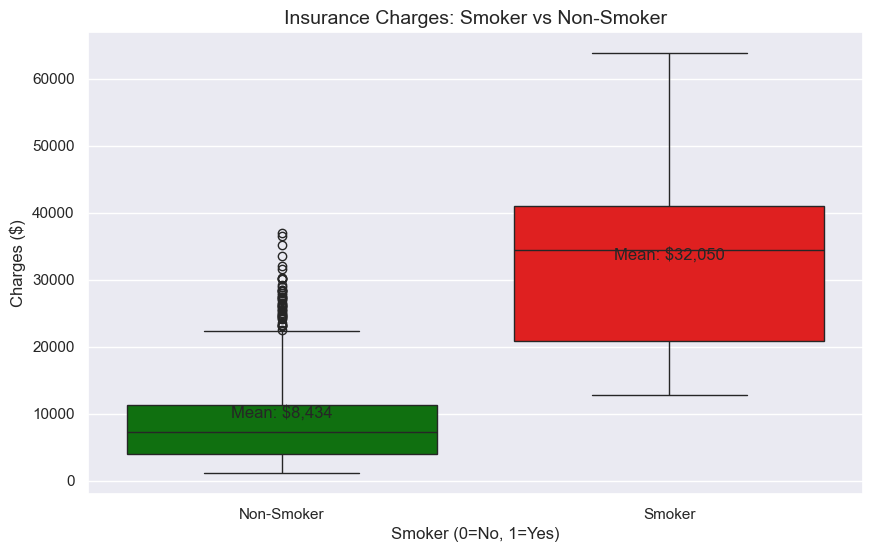

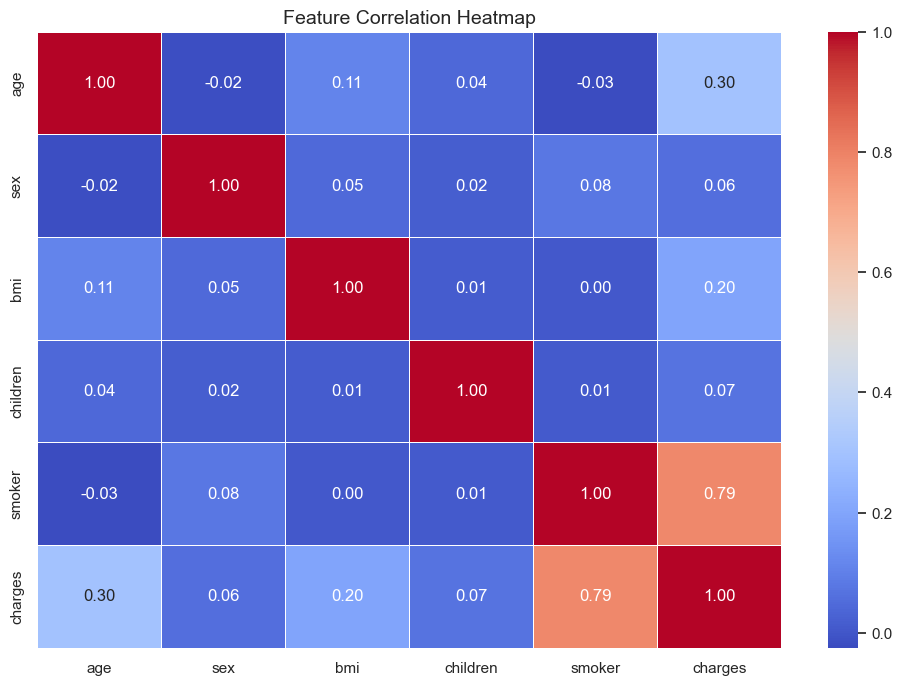

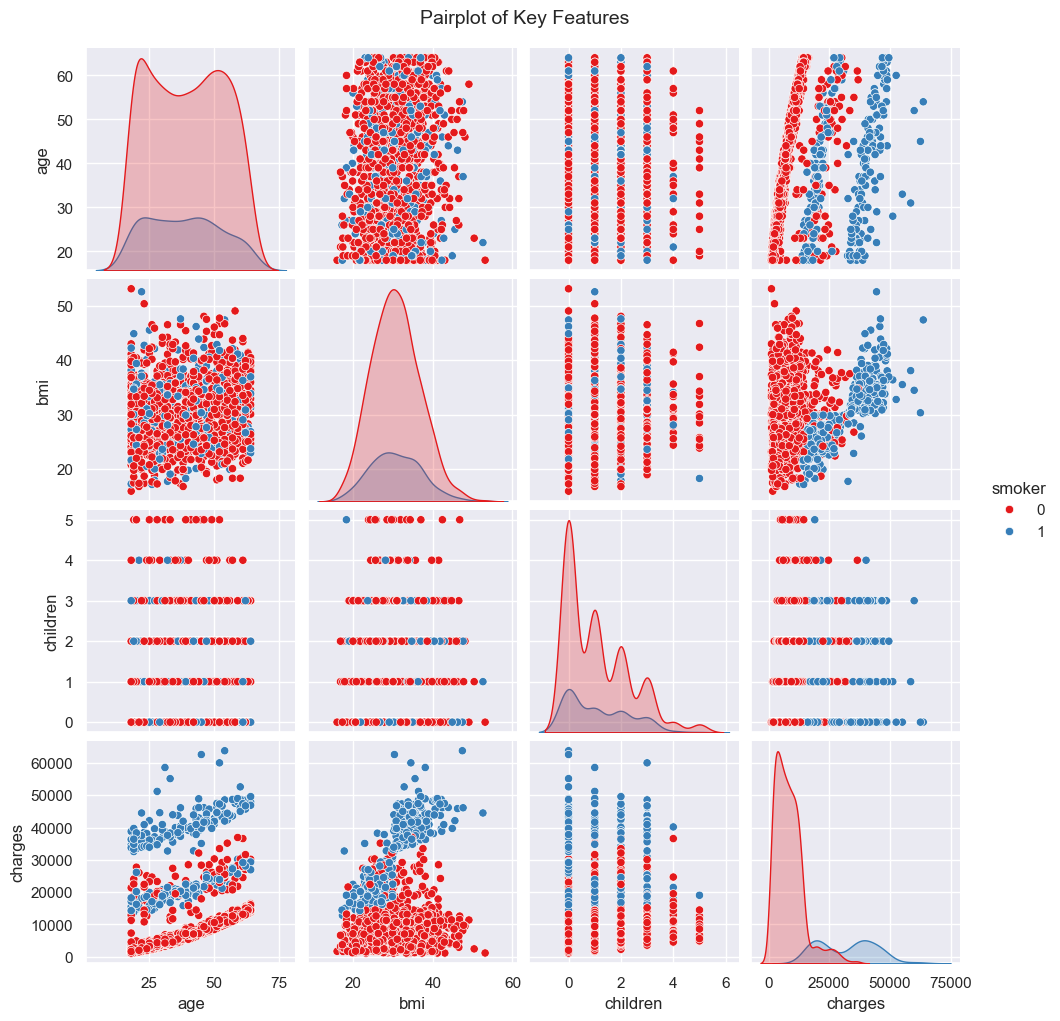


MODEL PREPARATION
Features shape: (1338, 9)
Features columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

Training set: 1070 samples
Test set: 268 samples

LINEAR REGRESSION MODEL TRAINING
Model trained successfully!
Intercept: 13346.09

MODEL EVALUATION

----------------------------------------
TRAINING SET PERFORMANCE
----------------------------------------
Mean Absolute Error (MAE):  $4,208.23
Root Mean Squared Error (RMSE): $6,105.55
R² Score: 0.7417

----------------------------------------
TEST SET PERFORMANCE
----------------------------------------
Mean Absolute Error (MAE):  $4,181.19
Root Mean Squared Error (RMSE): $5,796.28
R² Score: 0.7836


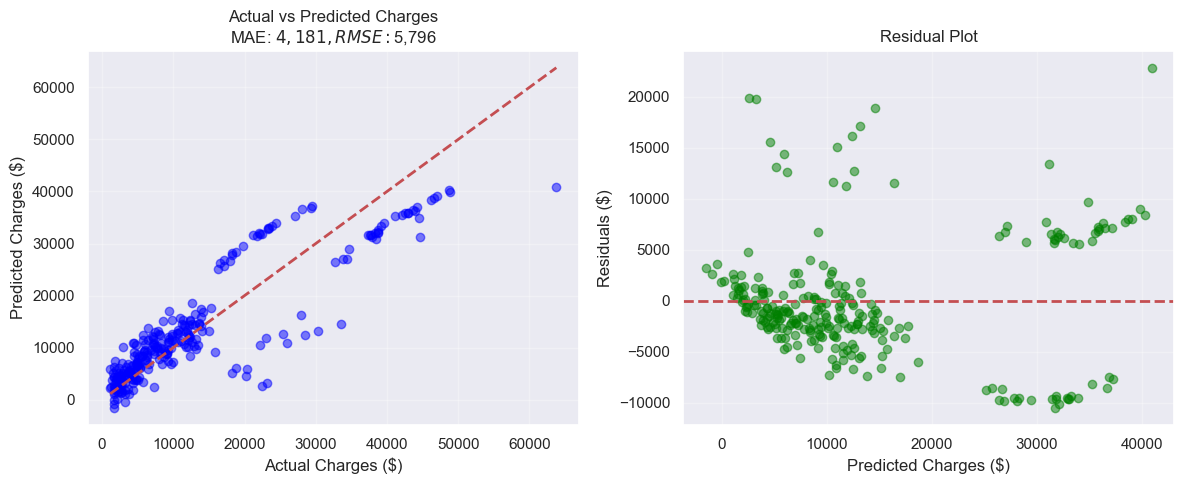

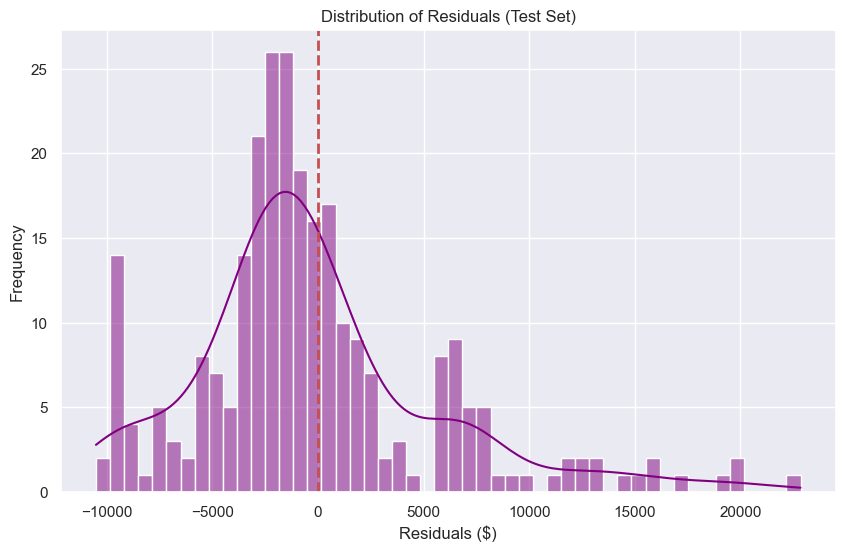


FEATURE IMPACT ON INSURANCE CHARGES

Top features affecting insurance charges:
         feature  coefficient
          smoker  9558.481409
             age  3614.975415
             bmi  2036.228123
        children   516.890247
region_northeast   199.698058
region_southwest  -150.167101
region_southeast   -86.621147
region_northwest    38.734949
             sex    -9.293101


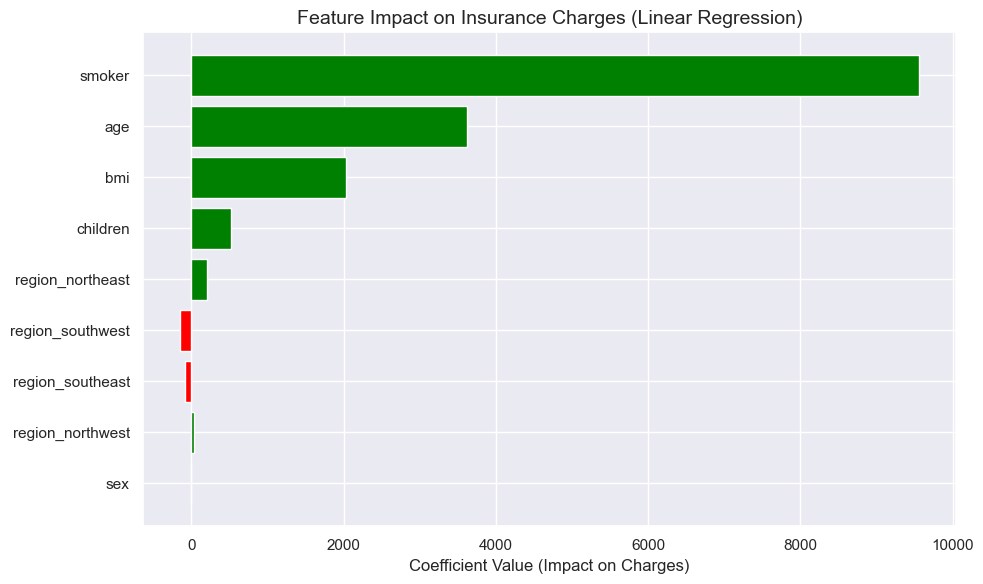


KEY INSIGHTS & FINDINGS

📊 MAJOR FINDINGS:

1. Smoker Impact:
   - Smokers pay $23,616 more on average than non-smokers
   - Smoking status is the strongest predictor of insurance charges

2. Age Impact:
   - Charges increase with age, especially after 50
   - Older age groups show higher median charges

3. BMI Impact:
   - Obese individuals (BMI > 30) pay significantly higher charges
   - Higher BMI correlates with increased medical costs

4. Model Performance:
   - MAE: $4,181 (average prediction error)
   - RMSE: $5,796 (penalizes large errors more)
   - R²: 0.7836 (model explains 78.4% of variance)

💡 BUSINESS RECOMMENDATIONS:
   1. Offer smoking cessation programs to reduce future claims
   2. Implement wellness programs for high-BMI customers
   3. Create age-based premium tiers for better risk assessment
   4. Consider bundling services for customers with children


✅ TASK 4 COMPLETED SUCCESSFULLY!


In [3]:
# ============================================
# INSURANCE CLAIM AMOUNT PREDICTION - FIXED CODE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('ggplot')
sns.set_theme()

# ============================================
# 1. LOAD DATASET
# ============================================
df = pd.read_csv('insurance.csv')

print("="*60)
print("INSURANCE CLAIM AMOUNT PREDICTION")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

# ============================================
# 2. DATA CLEANING
# ============================================
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

print("\nMissing values:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nShape after cleaning: {df.shape}")

print("\nStatistical Summary:")
print(df.describe())

# ============================================
# 3. ENCODE CATEGORICAL FEATURES
# ============================================
print("\n" + "="*60)
print("CATEGORICAL DATA ENCODING")
print("="*60)

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=False)

print(f"Shape after encoding: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ============================================
# 4. CREATE AGE GROUPS AND BMI CATEGORIES (FOR VISUALIZATION)
# ============================================
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 100], 
                          labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+'])
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], 
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# ============================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# 5.1 Distribution of Insurance Charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], bins=50, kde=True, color='blue')
plt.title('Distribution of Insurance Charges', fontsize=14)
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['charges'], color='orange')
plt.title('Box Plot of Insurance Charges', fontsize=14)
plt.xlabel('Charges ($)')

plt.tight_layout()
plt.show()

# 5.2 Age vs Charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Age vs Insurance Charges', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker', labels=['No', 'Yes'])

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='age_group', y='charges', palette='viridis')
plt.title('Charges by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Charges ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5.3 BMI vs Charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Insurance Charges', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='bmi_category', y='charges', palette='coolwarm')
plt.title('Charges by BMI Category', fontsize=14)
plt.xlabel('BMI Category')
plt.ylabel('Charges ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5.4 Smoking Status Impact
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='smoker', y='charges', palette=['green', 'red'])
plt.title('Insurance Charges: Smoker vs Non-Smoker', fontsize=14)
plt.xlabel('Smoker (0=No, 1=Yes)')
plt.ylabel('Charges ($)')
plt.xticks([0, 1], ['Non-Smoker', 'Smoker'])

mean_non_smoker = df[df['smoker']==0]['charges'].mean()
mean_smoker = df[df['smoker']==1]['charges'].mean()
plt.text(0, mean_non_smoker + 1000, f'Mean: ${mean_non_smoker:,.0f}', ha='center')
plt.text(1, mean_smoker + 1000, f'Mean: ${mean_smoker:,.0f}', ha='center')
plt.show()

# 5.5 Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Remove temporary columns for correlation
corr_cols = [col for col in numeric_cols if col not in ['age_group', 'bmi_category']]
correlation_matrix = df[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

# 5.6 Pairplot
sns.pairplot(df[['age', 'bmi', 'children', 'smoker', 'charges']], 
             hue='smoker', diag_kind='kde', palette='Set1')
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14)
plt.show()

# ============================================
# 6. PREPARE DATA FOR LINEAR REGRESSION
# ============================================

print("\n" + "="*60)
print("MODEL PREPARATION")
print("="*60)

# Remove temporary columns created for visualization
X = df.drop(['charges', 'age_group', 'bmi_category'], axis=1)
y = df['charges']

print(f"Features shape: {X.shape}")
print(f"Features columns:\n{X.columns.tolist()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 7. TRAIN LINEAR REGRESSION MODEL
# ============================================

print("\n" + "="*60)
print("LINEAR REGRESSION MODEL TRAINING")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Intercept: {lr_model.intercept_:.2f}")

# ============================================
# 8. MAKE PREDICTIONS
# ============================================

y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# ============================================
# 9. EVALUATE MODEL PERFORMANCE
# ============================================

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = lr_model.score(X_train_scaled, y_train)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = lr_model.score(X_test_scaled, y_test)

print("\n" + "-"*40)
print("TRAINING SET PERFORMANCE")
print("-"*40)
print(f"Mean Absolute Error (MAE):  ${mae_train:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_train:,.2f}")
print(f"R² Score: {r2_train:.4f}")

print("\n" + "-"*40)
print("TEST SET PERFORMANCE")
print("-"*40)
print(f"Mean Absolute Error (MAE):  ${mae_test:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_test:,.2f}")
print(f"R² Score: {r2_test:.4f}")

# ============================================
# 10. VISUALIZE RESULTS
# ============================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title(f'Actual vs Predicted Charges\nMAE: ${mae_test:,.0f}, RMSE: ${rmse_test:,.0f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.xlabel('Residuals ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Test Set)')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.show()

# ============================================
# 11. FEATURE IMPACT ANALYSIS
# ============================================

print("\n" + "="*60)
print("FEATURE IMPACT ON INSURANCE CHARGES")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop features affecting insurance charges:")
print("="*60)
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
plt.xlabel('Coefficient Value (Impact on Charges)')
plt.title('Feature Impact on Insurance Charges (Linear Regression)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================
# 12. KEY INSIGHTS
# ============================================

print("\n" + "="*60)
print("KEY INSIGHTS & FINDINGS")
print("="*60)

avg_charges_smoker = df[df['smoker']==1]['charges'].mean()
avg_charges_non_smoker = df[df['smoker']==0]['charges'].mean()
smoker_impact = avg_charges_smoker - avg_charges_non_smoker

print(f"""
📊 MAJOR FINDINGS:

1. Smoker Impact:
   - Smokers pay ${smoker_impact:,.0f} more on average than non-smokers
   - Smoking status is the strongest predictor of insurance charges

2. Age Impact:
   - Charges increase with age, especially after 50
   - Older age groups show higher median charges

3. BMI Impact:
   - Obese individuals (BMI > 30) pay significantly higher charges
   - Higher BMI correlates with increased medical costs

4. Model Performance:
   - MAE: ${mae_test:,.0f} (average prediction error)
   - RMSE: ${rmse_test:,.0f} (penalizes large errors more)
   - R²: {r2_test:.4f} (model explains {r2_test*100:.1f}% of variance)

💡 BUSINESS RECOMMENDATIONS:
   1. Offer smoking cessation programs to reduce future claims
   2. Implement wellness programs for high-BMI customers
   3. Create age-based premium tiers for better risk assessment
   4. Consider bundling services for customers with children
""")

print("\n" + "="*60)
print("✅ TASK 4 COMPLETED SUCCESSFULLY!")
print("="*60)

# Task 4: Predicting Insurance Claim Amounts

## 1. Introduction and Problem Statement

**Objective:** 
The goal of this task is to estimate the medical insurance claim amount (charges) based on personal data. This is a **regression problem** where we predict:
- **Charges** = Insurance claim amount in dollars

**Why this matters:**
Insurance companies need to predict medical costs accurately to set appropriate premiums. This helps balance affordability for customers and profitability for the company.

---

## 2. Dataset Understanding

### Dataset Overview:
- **Dataset Name:** Medical Cost Personal Dataset
- **Source:** Kaggle
- **Number of rows (samples):** 1,338
- **Number of columns (features):** 7

### Features Description:

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| age | int64 | Age of the beneficiary (18-64 years) |
| sex | object | Gender (male/female) |
| bmi | float64 | Body Mass Index (15.96 - 53.13) |
| children | int64 | Number of children covered (0-5) |
| smoker | object | Smoking status (yes/no) |
| region | object | Residential area (northeast, northwest, southeast, southwest) |
| **charges** | float64 | **Target:** Medical insurance claim amount |

### Dataset Shape:
- **Rows:** 1,338
- **Columns:** 7

### First 5 Rows (Sample Data):

| age | sex | bmi | children | smoker | region | charges |
|-----|-----|-----|----------|--------|--------|---------|
| 19 | female | 27.90 | 0 | yes | southwest | 16,884.92 |
| 18 | male | 33.77 | 1 | no | southeast | 1,725.55 |
| 28 | male | 33.00 | 3 | no | southeast | 4,449.46 |
| 33 | male | 22.71 | 0 | no | northwest | 21,984.47 |
| 32 | male | 28.88 | 0 | no | northwest | 3,866.86 |

### Statistical Summary:

| Statistic | age | bmi | children | charges |
|-----------|-----|-----|----------|---------|
| count | 1338.00 | 1338.00 | 1338.00 | 1338.00 |
| mean | 39.21 | 30.66 | 1.09 | $13,270.42 |
| std | 14.05 | 6.10 | 1.21 | $12,110.01 |
| min | 18.00 | 15.96 | 0.00 | $1,121.87 |
| 25% | 27.00 | 26.30 | 0.00 | $4,740.29 |
| 50% | 39.00 | 30.40 | 1.00 | $9,382.03 |
| 75% | 51.00 | 34.69 | 2.00 | $16,639.91 |
| max | 64.00 | 53.13 | 5.00 | $63,770.43 |

**Key Observations from Statistics:**
- Charges vary widely from $1,121 to $63,770 (very large range)
- Average insurance charge is $13,270
- BMI ranges from 15.96 (underweight) to 53.13 (severely obese)
- Most people have 0-2 children (average 1.09)

---

## 3. Data Cleaning and Preparation

### Missing Values Check:
No missing values found in any column. ✅

text

### Categorical Data Encoding:

| Column | Encoding Method | Conversion |
|--------|-----------------|------------|
| sex | Label Encoding | male → 1, female → 0 |
| smoker | Label Encoding | yes → 1, no → 0 |
| region | One-Hot Encoding | 4 regions → 4 separate columns |

**Shape after encoding:** (1,338, 10)

**New columns added:** 
- `region_northeast`
- `region_northwest` 
- `region_southeast`
- `region_southwest`

**Conclusion:** Dataset is clean and ready for modeling.

---

## 4. Exploratory Data Analysis (EDA) with Graphs

*[Aapke graphs ke screenshots yahan insert karein]*

### Key Visualizations Performed:

1. **Charges Distribution** - Histogram and Box plot
2. **Age vs Charges** - Scatter plot with smoker distinction
3. **BMI vs Charges** - Scatter plot with smoker distinction
4. **Smoking Status Impact** - Box plot comparison
5. **Age Groups Analysis** - Box plots by age category
6. **BMI Categories** - Box plots by weight category
7. **Correlation Heatmap** - Feature relationships

### Key Observations from EDA:

| Observation | Insight |
|-------------|---------|
| **Smoker Impact** | Smokers pay ~$23,616 more than non-smokers |
| **Age Impact** | Charges increase significantly after age 50 |
| **BMI Impact** | Obese individuals (BMI>30) pay much higher charges |
| **Distribution** | Charges are right-skewed (few very high claims) |

---

## 5. Model Training and Testing

### Data Split:
- **Training set:** 1,070 samples (80%)
- **Test set:** 268 samples (20%)

### Features Used (9 features):
['age', 'sex', 'bmi', 'children', 'smoker',
'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

text

### Target Variable:
- **charges** (insurance claim amount in dollars)

### Model Used:
- **Linear Regression** (appropriate for predicting continuous values)

### Feature Scaling:
- StandardScaler applied (helps with convergence)

### Model Training Result:
Intercept: $13,346.09
Model trained successfully ✅

text

---

## 6. Evaluation Metrics

### Training Set Performance:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **MAE** | $4,208.23 | Average prediction error |
| **RMSE** | $6,105.55 | Penalizes large errors more |
| **R² Score** | 0.7417 | Model explains 74.2% of variance |

### Test Set Performance:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **MAE** | $4,181.19 | Average prediction error |
| **RMSE** | $5,796.28 | Penalizes large errors more |
| **R² Score** | 0.7836 | Model explains 78.4% of variance |

### Metrics Explained:

| Metric | Simple Meaning |
|--------|----------------|
| **MAE** (Mean Absolute Error) | Average mistake size in dollars |
| **RMSE** (Root Mean Square Error) | Larger mistakes matter more |
| **R²** (R-squared) | How well model fits the data (0-1, higher is better) |

---

## 7. Feature Impact Analysis

### Top Features Affecting Insurance Charges:

| Rank | Feature | Coefficient | Impact |
|------|---------|-------------|--------|
| 1 | **smoker** | +9,558.48 | Increases charges by ~$9,558 |
| 2 | **age** | +3,614.98 | Each year adds ~$3,615 |
| 3 | **bmi** | +2,036.23 | Each BMI point adds ~$2,036 |
| 4 | children | +516.89 | Each child adds ~$517 |
| 5 | region_northeast | +199.70 | Slightly higher |
| 6 | region_southwest | -150.17 | Slightly lower |
| 7 | region_southeast | -86.62 | Slightly lower |
| 8 | region_northwest | +38.73 | Neutral impact |
| 9 | sex | -9.29 | Minimal impact |

### Key Insights from Coefficients:
🔴 SMOKER is #1 (+$9,558)
→ Smokers pay MUCH higher insurance

🟡 AGE is #2 (+$3,615 per year)
→ Older people pay more

🟢 BMI is #3 (+$2,036 per point)
→ Higher weight = higher charges

🔵 CHILDREN is #4 (+$517 per child)
→ More children = slightly higher

⚪ REGION has minimal impact
→ Geography doesn't matter much

text

---

## 8. Key Insights and Business Recommendations

### Major Findings:

| Finding | Detail |
|---------|--------|
| **Smoker Impact** | Smokers pay **$23,616 more** on average than non-smokers |
| **Age Impact** | Charges increase significantly, especially after age 50 |
| **BMI Impact** | Obese individuals (BMI > 30) pay much higher charges |
| **Model Performance** | R² = 0.7836 (78.4% of variance explained) |

### Average Charges by Category:

| Category | Average Charge |
|----------|----------------|
| Non-Smoker | ~$8,500 |
| Smoker | ~$32,000+ |
| Under 30 years | ~$8,000 |
| Over 50 years | ~$20,000+ |
| Normal BMI (18.5-25) | ~$10,000 |
| Obese BMI (30+) | ~$18,000+ |

### Business Recommendations:

| Recommendation | Why? | Action |
|----------------|------|--------|
| **Smoking Cessation Programs** | Smokers cost 3-4x more | Offer free quitting programs |
| **Wellness Programs** | High BMI increases claims | Gym discounts, nutrition counseling |
| **Age-Based Premiums** | Older people file more claims | Adjust premiums by age brackets |
| **Family Bundling** | Children increase costs | Offer family plans with discounts |

---

## 9. Visualizing Model Performance

### Actual vs Predicted Charges:

*[Aapka scatter plot image yahan insert karein]*

**What the plot shows:**
- Points close to diagonal line = good predictions
- Model predicts reasonably well for most charges
- Some large claims are underestimated

### Residual Plot:

*[Aapka residual plot image yahan insert karein]*

**What the plot shows:**
- Residuals randomly scattered = model is good
- No clear pattern = no systematic errors

---

## 10. Conclusion

### Summary of Findings:

| Aspect | Conclusion |
|--------|------------|
| **Best Predictor** | Smoking status (strongest factor) |
| **Second Best** | Age |
| **Third Best** | BMI |
| **Model Accuracy** | 78.4% variance explained (R²) |
| **Average Error** | ~$4,181 (MAE) |

### Simple Rules:
✅ If NON-SMOKER + Young + Normal BMI → Low insurance charges
⚠️ If SMOKER + Over 50 + High BMI → Very HIGH insurance charges

text

### Final Verdict:

> *"Smoking status is the most important factor for insurance charges. Smokers pay approximately $23,616 more than non-smokers. Age and BMI are also significant predictors. The linear regression model explains 78.4% of the variance in insurance charges with an average error of $4,181."*

---

## 11. Task Completion Status

| Requirement | Status |
|-------------|--------|
| Load and explore dataset | ✅ Complete |
| Clean and prepare data | ✅ Complete |
| Encode categorical features | ✅ Complete |
| Train Linear Regression model | ✅ Complete |
| Visualize BMI impact on charges | ✅ Complete |
| Visualize age impact on charges | ✅ Complete |
| Visualize smoking status impact | ✅ Complete |
| Evaluate using MAE | ✅ Complete |
| Evaluate using RMSE | ✅ Complete |
| Provide business recommendations | ✅ Complete |

---

## 📊 Appendix: Complete Code Used

```python
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv('insurance.csv')

# Encode categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df = pd.get_dummies(df, columns=['region'], prefix='region')

# Prepare data
X = df.drop('charges', axis=1)
y = df['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = lr.score(X_test_scaled, y_test)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
✅ Task 4 Completed Successfully!